In [25]:
import pandas as pd

df = pd.read_csv('dataset.csv')
df

,customer_id,customer_name,product,contract_type,tenure_months,monthly_charge_gbp,payment_delays_last_6mo,num_complaints_last_6mo,open_tickets,days_since_last_contact,satisfaction_score,nps_score,last_contact_channel,payment_method,latest_support_transcript,ground_truth_risk
0,CUST-0001,Customer 1,Business Starter,Annual,53,94.47,0,1,0,79,4.2,7,Email,Credit Card,I'd love to join your beta programme for new f...,Low
1,CUST-0002,Customer 2,Premium Add-on,Monthly,12,212.55,3,4,0,4,1.9,0,Phone,Invoice,The service went down during a critical client...,High
2,CUST-0003,Customer 3,Pro Plan,Monthly,12,145.71,0,0,1,3,3.9,4,Email,Invoice,The service has been a bit slow lately. Not a ...,Medium
3,CUST-0004,Customer 4,Premium Add-on,Two-Year,35,104.44,0,0,0,106,4.0,7,Web Form,Credit Card,I've been recommending your service to a few c...,Low
4,CUST-0005,Customer 5,Enterprise Suite,Annual,27,77.11,2,0,0,27,3.1,1,Email,Invoice,I'd like to discuss my contract before it auto...,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,CUST-1496,Customer 1496,Enterprise Suite,Two-Year,45,101.50,0,0,0,98,3.9,8,Chat,Direct Debit,Just a heads up — I'll be out of office for tw...,Low
1496,CUST-1497,Customer 1497,Premium Add-on,Monthly,22,50.00,4,2,1,1,1.2,0,Chat,Direct Debit,I'm being billed for a plan I downgraded from ...,High
1497,CUST-1498,Customer 1498,Premium Add-on,Monthly,31,59.46,1,4,0,20,2.2,4,Email,Direct Debit,The service has been a bit slow lately. Not a ...,Medium
1498,CUST-1499,Customer 1499,Enterprise Suite,Monthly,25,223.24,4,6,1,1,3.3,5,Email,Direct Debit,My team can't access the platform and we have ...,High


## Data Preprocessing

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                1500 non-null   str    
 1   customer_name              1500 non-null   str    
 2   product                    1500 non-null   str    
 3   contract_type              1500 non-null   str    
 4   tenure_months              1500 non-null   int64  
 5   monthly_charge_gbp         1500 non-null   float64
 6   payment_delays_last_6mo    1500 non-null   int64  
 7   num_complaints_last_6mo    1500 non-null   int64  
 8   open_tickets               1500 non-null   int64  
 9   days_since_last_contact    1500 non-null   int64  
 10  satisfaction_score         1500 non-null   float64
 11  nps_score                  1500 non-null   int64  
 12  last_contact_channel       1500 non-null   str    
 13  payment_method             1500 non-null   str    
 14  lat

### Check for null values

In [5]:
df.isna().sum()

customer_id                  0
customer_name                0
product                      0
contract_type                0
tenure_months                0
monthly_charge_gbp           0
payment_delays_last_6mo      0
num_complaints_last_6mo      0
open_tickets                 0
days_since_last_contact      0
satisfaction_score           0
nps_score                    0
last_contact_channel         0
payment_method               0
latest_support_transcript    0
ground_truth_risk            0
dtype: int64

### Correlation Matrix


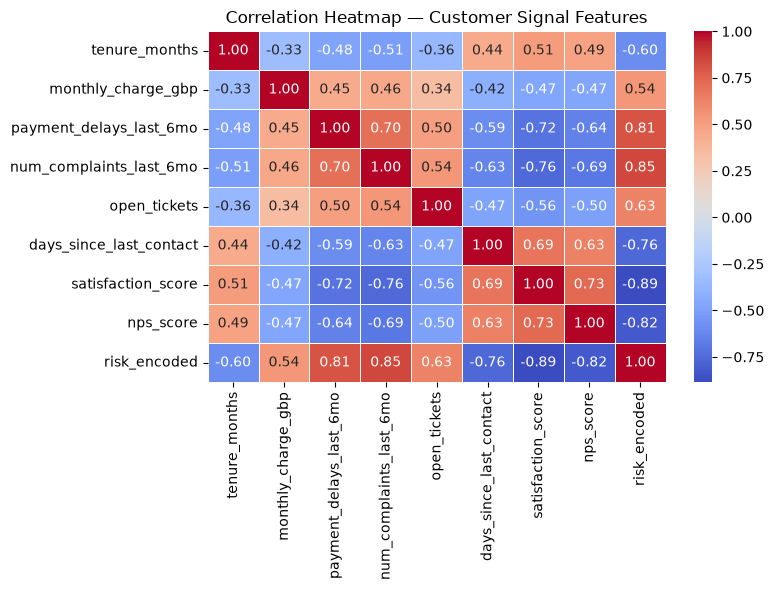

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = [
    "tenure_months",
    "monthly_charge_gbp",
    "payment_delays_last_6mo",
    "num_complaints_last_6mo",
    "open_tickets",
    "days_since_last_contact",
    "satisfaction_score",
    "nps_score"
]

# Encode target as numeric so it appears in the matrix
risk_map = {"Low": 0, "Medium": 1, "High": 2}
df["risk_encoded"] = df["ground_truth_risk"].map(risk_map)

matrix = df[numerical_cols + ["risk_encoded"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap — Customer Signal Features")
plt.tight_layout()
plt.show()

### Turn categorical values into numerical with one-hot encoding

In [28]:
risk_map = {"Monthly": 0, "Annual": 1, "Two-Year": 2}
df["contract_type_encoded"] = df["contract_type"].map(risk_map)


categorical_cols = ["payment_method", "last_contact_channel", "product"]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=False,  dtype='int')

In [21]:
df

,customer_id,customer_name,contract_type,tenure_months,monthly_charge_gbp,payment_delays_last_6mo,num_complaints_last_6mo,open_tickets,days_since_last_contact,satisfaction_score,...,payment_method_Invoice,last_contact_channel_Chat,last_contact_channel_Email,last_contact_channel_Phone,last_contact_channel_Web Form,product_Business Starter,product_Enterprise Suite,product_Premium Add-on,product_Pro Plan,product_Team Plan
0,CUST-0001,Customer 1,Annual,15,121.57,0,0,0,99,4.0,...,0,0,0,0,1,0,0,1,0,0
1,CUST-0002,Customer 2,Annual,14,131.19,6,3,4,8,1.8,...,0,0,0,1,0,1,0,0,0,0
2,CUST-0003,Customer 3,Two-Year,55,70.57,0,1,0,75,3.9,...,0,1,0,0,0,0,0,1,0,0
3,CUST-0004,Customer 4,Two-Year,80,53.73,1,0,0,76,4.5,...,1,0,0,1,0,0,1,0,0,0
4,CUST-0005,Customer 5,Monthly,19,296.75,3,3,3,6,1.6,...,1,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,CUST-0996,Customer 996,Annual,16,135.15,2,2,1,15,3.4,...,0,1,0,0,0,0,0,1,0,0
996,CUST-0997,Customer 997,Annual,20,54.20,1,3,0,30,2.9,...,0,0,1,0,0,0,0,0,0,1
997,CUST-0998,Customer 998,Two-Year,76,74.57,1,1,0,51,4.8,...,0,0,0,0,1,0,0,0,1,0
998,CUST-0999,Customer 999,Monthly,5,155.32,4,4,1,4,1.3,...,1,0,0,0,1,0,0,0,0,1


In [18]:
df.columns


Index(['customer_id', 'customer_name', 'contract_type', 'tenure_months',
       'monthly_charge_gbp', 'payment_delays_last_6mo',
       'num_complaints_last_6mo', 'open_tickets', 'days_since_last_contact',
       'satisfaction_score', 'nps_score', 'latest_support_transcript',
       'ground_truth_risk', 'risk_encoded', 'contract_type_encoded',
       'payment_method_Credit Card', 'payment_method_Direct Debit',
       'payment_method_Invoice', 'last_contact_channel_Chat',
       'last_contact_channel_Email', 'last_contact_channel_Phone',
       'last_contact_channel_Web Form', 'product_Business Starter',
       'product_Enterprise Suite', 'product_Premium Add-on',
       'product_Pro Plan', 'product_Team Plan'],
      dtype='str')

### Dataset splitting

In [29]:
from sklearn.model_selection import train_test_split

drop_cols = ["customer_id", "customer_name", "latest_support_transcript", "ground_truth_risk", "risk_encoded", "contract_type"]
X = df.drop(columns=drop_cols)
y = df['risk_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)

### Random Forest Classifier

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

grid_search = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced', 
        max_features='sqrt',
        min_samples_leaf=2,      
        random_state=42,          
        n_jobs=-1                 
    ),
    param_grid={
        'n_estimators': [100, 200],
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5]
    },
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

clf = grid_search.best_estimator_
print(f"Best params: {grid_search.best_params_}")

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['High', 'Low', 'Medium']))

Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

        High       1.00      0.99      0.99       139
         Low       0.96      0.99      0.98        83
      Medium       0.99      0.99      0.99        78

    accuracy                           0.99       300
   macro avg       0.98      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



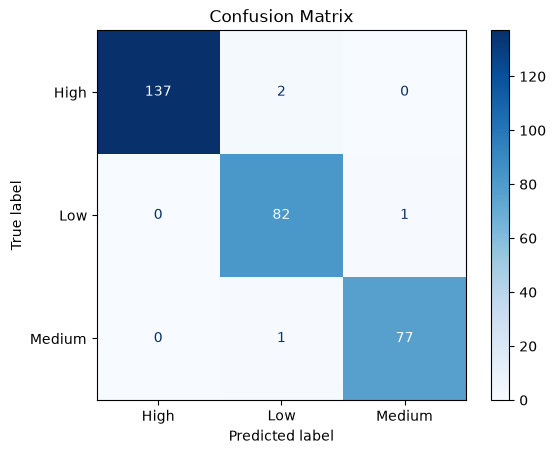

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['High', 'Low', 'Medium'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

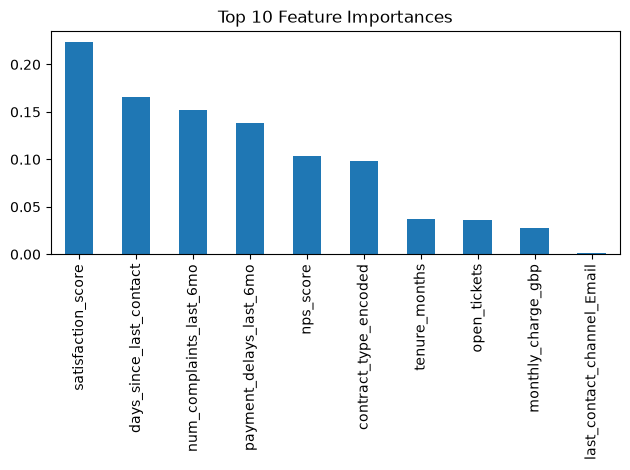

In [35]:
feature_importance = pd.Series(
    clf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
probabilities = clf.predict_proba(X_test)
high_risk_index = list(clf.classes_).index(2) #High
risk_scores = (probabilities[:, high_risk_index] * 10).round(1)

print(risk_scores)

[ 0.   0.   9.4 10.   9.9  0.1  8.7  0.   0.  10.   0.4  0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   8.   6.6  0.   0.  10.   8.5  0.
 10.   3.5  0.   0.   0.   0.   9.8  6.6  0.   8.6  0.4  0.8  0.   0.9
  0.   0.   0.8  0.1  9.9  0.2  0.2  0.   7.7  0.   0.1  9.6  0.6  0.
  0.   0.   0.   0.5  0.   0.   0.   0.   1.5 10.  10.   0.4  0.   0.
  1.4  0.   0.   9.5  0.   0.9  9.2  0.   0.   0.   0.   0.5  6.9  9.4
  0.   0.   0.1  8.6  9.5  0.   0.   0.   0.   3.6  1.2  1.1  0.   3.6
  0.5  0.   0.   0.   0.   0.   8.6  0.1  0.   9.9  8.9  0.   0.   9.9
  0.   0.1  0.   0.   0.   0.   0.   0.   0.1  0.   9.6  0.   7.5  0.
  0.   0.   9.6  0.   0.   8.2  0.   0.2  0.   0.   0.   0.  10.   0.
  9.2  8.9  0.   0.3 10.   0.2  0.   0.   1.1  0.   9.4  8.   0.   0.
  0.   2.6  8.8  0.   9.8  0.   0.  10.   0.   0.   0.   0.   0.   0.
  0.   2.3  2.1  0.   0.1  0.1  0.1  8.   0.  10.   0.   0.   0.   0.
  9.   9.1  0.   0.1  9.4  0.   7.4  0.   0.3  0.   0.   0.8  0.   0.
  9.8  0.   8.8 

In [ ]:
import anthropic
import json
import pandas as pd
from config import CLAUDE_API

client = anthropic.Anthropic(api_key=CLAUDE_API)

def analyse_transcript(row):
    prompt = f"""
    You are a customer retention analyst. You will be given some information about the customer's billing data and support transcript, 
    which are a few sentences with the customer's feedback.
    Analyse the following customer signals and return ONLY a JSON object with no additional text.

    Customer signals:
    - Tenure: {row['tenure_months']} months
    - Monthly charge: £{row['monthly_charge_gbp']}
    - Payment delays (last 6 months): {row['payment_delays_last_6mo']}
    - Number of complaints (last 6 months): {row['num_complaints_last_6mo']}
    - Satisfaction score: {row['satisfaction_score']}/5
    - NPS score: {row['nps_score']}/10
    - Open tickets: {row['open_tickets']}
    - Support transcript: "{row['latest_support_transcript']}"

    Return this exact JSON structure:
    {{
        "sentiment": "Frustrated" or "Neutral" or "Positive",
        "rationale": "2 sentence explanation of why this customer is or isn't at risk",
        "recommended_action": "one specific retention action for the team"
    }}
    """

    try:
        response = client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=500,
            messages=[{"role": "user", "content": prompt}]
        )
        raw = response.content[0].text.strip()
        
        # Strip markdown backticks if Claude wraps in ```json ... ```
        if raw.startswith("```"):
            raw = raw.split("```")[1]
            if raw.startswith("json"):
                raw = raw[4:]
        
        return json.loads(raw.strip())

    except Exception as e:
        print(f"Error on customer {row['customer_id']}: {e}")
        return {
            "sentiment": "Unknown",
            "rationale": "Analysis unavailable.",
            "recommended_action": "Manual review required."
        }



sentiments = []
rationales = []
actions = []
df_sample = df[10:20]
for _, row in df_sample.iterrows():
    result = analyse_transcript(row)
    sentiments.append(result["sentiment"])
    rationales.append(result["rationale"])
    actions.append(result["recommended_action"])

df_sample["sentiment"] = sentiments
df_sample["rationale"] = rationales
df_sample["recommended_action"] = actions

In [58]:
pd.set_option('display.max_colwidth', None)
df_sample.iloc[:, -3:]

,sentiment,rationale,recommended_action
10,Positive,"This customer demonstrates strong loyalty signals with 41 months of tenure, zero complaints, zero open tickets, and a positive support interaction where they self-attributed a minor issue. Their satisfaction score of 3.9/5 and NPS of 7/10 indicate general contentment, though there is modest room for improvement given their relatively high monthly charge of £114.28.","Proactively reach out with a loyalty reward or exclusive discount on their current plan to reinforce satisfaction and elevate their NPS from a passive 7 to a promoter, reducing any latent price-sensitivity risk."
11,Frustrated,"This customer shows multiple high-risk signals including a low satisfaction score of 2.6/5, a detractor-level NPS of 4/10, and 3 complaints in the last 6 months, indicating deepening dissatisfaction. Their support transcript reveals a core concern about product stagnation on a feature critical to their workflow, suggesting they may be actively evaluating alternatives despite a 20-month tenure.","Assign a dedicated account manager to proactively reach out with a personalised roadmap update for the specific feature in question, and offer a temporary loyalty discount to reinforce commitment while development progress is communicated."
12,Positive,"This long-tenured customer of over 4 years shows strong engagement signals with zero complaints, zero payment delays, and an above-average satisfaction score, while actively expressing enthusiasm for deeper product involvement. Their interest in the beta programme indicates high product investment and a forward-looking relationship, making churn risk very low.",Enrol the customer in the beta programme immediately and assign them a dedicated product liaison to nurture their advocate status and gather valuable early feedback.
13,Frustrated,"The customer shows multiple at-risk signals including a below-average satisfaction score (3.2/5), a low NPS of 4/10, 3 payment delays, and 2 complaints in the last 6 months, suggesting growing disengagement despite a reasonable 25-month tenure. The support transcript reveals that recurring billing discrepancies are eroding trust, and the customer's perception of a 'pattern' indicates that unresolved frustration could accelerate churn if not addressed promptly.","Assign a dedicated account manager to proactively reach out, acknowledge the billing discrepancies with a formal explanation and goodwill credit, and schedule a quarterly billing review to rebuild trust and demonstrate accountability."
14,Frustrated,"Despite a moderate tenure of 28 months, this customer shows significant churn risk signals including a very low NPS of 2/10, a mediocre satisfaction score of 3.0/5, 2 open tickets, and a recurring unresolved technical issue that erodes trust. The high monthly charge of £253.16 raises the stakes further, as the customer is paying a premium but experiencing repeated service failures without a lasting fix.",Assign a dedicated senior support engineer to conduct a root cause analysis on the recurring issue and schedule a proactive check-in call with the customer within 48 hours to present findings and a permanent resolution plan.
15,Neutral,"The customer has a moderate satisfaction score and a reasonably positive NPS, with no open complaints or tickets, suggesting they are not actively dissatisfied. However, the mention of reviewing software subscriptions combined with 2 recent payment delays signals a potential cost-cutting evaluation that could put their account at risk.","Proactively send a personalised plan breakdown highlighting key value metrics and usage ROI, and have an account manager schedule a brief check-in call to address any value concerns before the subscription review concludes."
16,Frustrated,"Despite no payment delays or open tickets, the customer's low satisfaction score (2.4/5) and NPS (5/10) combined with 2 recent complaints signal underlying dissatisfaction that could lead to churn. The suppor